## Processing of imaging data using max-projection (i.e. data compressed to 3D)

This preprocessing pipeline can be used to process  single-plane imaging data (3D) or volume imaging data (4D). In the latter case, the volume is collapsed through a max projection.

In [7]:
from ScanImageTiffReader import ScanImageTiffReader
import json
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import numpy as np
import matplotlib.patches as ppatch

from sys import path
from os.path import sep, exists
from os import mkdir, makedirs, getcwd

import napari #python -m pip install "napari[all]"
import xarray as xr
import pandas as pd

%gui qt5
%config Completer.use_jedi = False  #magic to fix autocomplete issue

In [8]:
#import shapely
from shapely.geometry.polygon import LinearRing, Polygon, LineString
from shapely.geometry.point import Point
#import matplotlib.affinity
import shapely.affinity

In [9]:
import os
import sys
import shutil
sys.executable

'c:\\Users\\stuarta\\AppData\\Local\\anaconda3\\envs\\fly2p\\python.exe'

In [10]:
from fly2p.viz.viz import myAxisTheme, plotDFFheatmap
import fly2p.preproc.imgPreproc as imp
from fly2p.preproc.scanImageUtils import getSIbasicMetadata, getSIMetadict, loadvolume
from fly2p.preproc.imgPreproc import genReference

In [11]:
from fly2p.viz.viz import generateEBellipse, constructEBROIs, plotEBshapelyROIs, getDFFfromEllipseROI

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Set paths to data files and plot directory

In [19]:
dataDir = r'\\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\R57C10_x_27F02-7f_SCaMP77\f23'
#dataDir = r'\\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\SS96_x_gCaMP7f\EB\f03'
rawTiff = 'f23_r57c10-scamp77_27f02-7f_96apf_t01_00001_00001.tif'


flyID = 'f23'
genotype = 'R57C10_x_27F02-7f_SCaMP77'
age='aprox96'
trial = 't01_30min'
region = 'dualcolorEPG_WB'
        
        


In [8]:
# import os
# import shutil
# import gc

# dirName = r'\\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\R57C10_x_27F02-7f_SCaMP77\chad_rig\aFly_0001'
# fileNameSI = '15degBar_1to2_00001.tif'
# srcPath = os.path.join(dirName, fileNameSI)

# tempDir = r'E:\tmp'
# os.makedirs(tempDir, exist_ok=True)
# tempPath = os.path.join(tempDir, fileNameSI)

# if os.path.exists(tempPath):
#     os.remove(tempPath)

# shutil.copyfile(srcPath, tempPath)

# try:
#     reader = ScanImageTiffReader(tempPath)
#     metadata_text = reader.metadata()

#     try:
#         reader.close()
#     except AttributeError:
#         pass
#     del reader
#     gc.collect()

#     imgMetadat = getSIbasicMetadata(metadata_text)
#     imgMetadat["CaCh"] = 1
#     SImetadict = getSIMetadict(metadata_text)

#     stack = loadvolume(tempPath, imgMetadat, selectCaChan=True)
#     imgStack = imp.stack2xarray(stack, imgMetadat)

#     print(imgMetadat)

# finally:
#     gc.collect()
#     if os.path.exists(tempPath):
#         os.remove(tempPath)

In [9]:
# stem = os.path.splitext(rawTiff)[0]
# parts = stem.split('_')
# flyID = parts[0]
# # trial_idx = next(i for i, p in enumerate(parts) if p.startswith('t'))
# # trial = parts[trial_idx] + '.' + parts[trial_idx+2]
# age = parts[trial_idx - 1]
# genotype = '_'.join(parts[1:trial_idx - 1])

# print(f'flyID: {flyID}')
# print(f'Genotype: {genotype}')
# print(f'Age: {age}')
# print(f'Trial: {trial}')

In [14]:
#saveDir = dataDir
#preprocDir = dataDir

saveDir = os.path.join(dataDir,trial)
preprocDir = os.path.join(dataDir,trial)

# Generate directory where to save plots
if not exists(saveDir): makedirs(saveDir)
if not exists(preprocDir): makedirs(preprocDir)

In [15]:
chan = 'green'
saveDir = os.path.join(dataDir,trial,chan)
preprocDir = os.path.join(dataDir,trial,chan)

# Generate directory where to save plots
if not exists(saveDir): makedirs(saveDir)
if not exists(preprocDir): makedirs(preprocDir)




#### Load data and perform motion correction

In [18]:
dataDir


'\\\\prfs.hhmi.org\\jayaramanlab\\Abby\\Data\\Fly2PImaging\\R57C10_x_27F02-7f_SCaMP77\\f23'

In [20]:
mytiffreader = ScanImageTiffReader(sep.join([dataDir, rawTiff]))
basicMetadat = getSIbasicMetadata(mytiffreader.metadata())
SImetadict = getSIMetadict(mytiffreader.metadata())

SI.VERSION_COMMIT = '3baa4b74bec9938bfd4c7403bddbe78f2a0ccd93'
SI.VERSION_MAJOR = 2021
SI.VERSION_MINOR = 0
SI.VERSION_UPDATE = 0


In [21]:
basicMetadat["CaCh"] = 0 # give channel identity

In [22]:
basicMetadat

{'nCh': 2,
 'fpsscan': 109.982,
 'discardFBFrames': 'true',
 'nDiscardFBFrames': 3,
 'fpv': 15,
 'nVols': 316656,
 'stackZStepSize': 4.0,
 'scanVolumeRate': 7.33216,
 'fovCoords': {'p00': [-30.6818, -30.6818],
  'p10': [30.6818, 30.6818],
  'p01': [30.6818, -30.6818],
  'p11': [-30.6818, 30.6818]},
 'xrange_um': 61.3636,
 'yrange_um': 61.3636,
 'CaCh': 0}

In [23]:
#Load data: With larger file sizes, the scanimage loader fails (idk why)
# stack = loadvolume(sep.join([dataDir, rawTiff]), basicMetadat, selectCaChan=True)

In [24]:
import re

def getFrameSplit(desc:str) -> int:
    m = re.search(r'frameNumbers\s*=\s*(\d+)', desc)
    if not m:
        raise RuntimeError("Could not find 'frameNumbers =' in TIFF description")
    return int(m.group(1))


In [25]:
import numpy as np
from skimage import io
import tifffile

def first_frame_count_from_tiff(path):
    with tifffile.TiffFile(path) as tf:
        desc = tf.pages[0].description
    return getFrameSplit(desc)

def loadSplitVolume(files, basicMetadat, selectCaChan=True, verbose=False):
    fpv = int(basicMetadat["fpv"])
    nfb = int(basicMetadat["nDiscardFBFrames"])
    ca  = int(basicMetadat["CaCh"])

    out = []
    carry = None

    # Align the FIRST file to the next volume boundary using firstFrameCount
    f0 = files[0]
    f0_first = int(first_frame_count_from_tiff(f0))  # 1-based global frame counter
    skip0 = (fpv - ((f0_first - 1) % fpv)) % fpv

    if verbose:
        print(f"Start file: {f0}")
        print(f" firstFrameCount={f0_first}, fpv={fpv}, skip_leading_frames={skip0}")

    for i, f in enumerate(files):
        frames = io.imread(f)

        # Accept either (t,y,x) or (t,ch,y,x); normalize to (t,y,x) by selecting Ca channel if needed
        if frames.ndim == 4:                 # (t, ch, y, x)
            if selectCaChan:
                frames = frames[:, ca, :, :] # -> (t, y, x)
            else:
                # if you truly want both channels later, keep 4D and adapt downstream
                raise ValueError(f"{f} is (t,ch,y,x); set selectCaChan=True or adapt code for both channels.")
        elif frames.ndim == 3:               # (t, y, x)
            pass
        else:
            raise ValueError(f"{f} has shape {frames.shape}; expected (t,y,x) or (t,ch,y,x).")

        # Apply the starting alignment only to the first file
        if i == 0 and skip0 > 0:
            frames = frames[skip0:]

        # Stitch leftovers from previous file
        if carry is not None and carry.shape[0] > 0:
            frames = np.concatenate([carry, frames], axis=0)

        nFrames = frames.shape[0]
        nVols = nFrames // fpv
        nUse = nVols * fpv

        if verbose:
            print(f"[{i}] {f}: frames_in={nFrames}, vols={nVols}, use={nUse}, carry_out={nFrames-nUse}")

        carry = frames[nUse:]  # < fpv frames

        if nVols == 0:
            continue

        vol = frames[:nUse].reshape(nVols, fpv, frames.shape[1], frames.shape[2])  # (nVols, fpv, y, x)

        if selectCaChan:
            vol = vol[:, :fpv - nfb, :, :]  # drop flyback planes

        out.append(vol)

    if verbose and carry is not None and carry.shape[0] > 0:
        print(f"WARNING: dropped trailing incomplete volume of {carry.shape[0]} frames")

    return np.concatenate(out, axis=0) if out else None



In [26]:
import os, glob

rawTiffs = rawTiff.rsplit('_', 1)[0] + '_*.tif'
all_files = sorted(glob.glob(os.path.join(dataDir, rawTiffs)))

chunkSize = slice(0,2)
chunk_files = all_files[chunkSize]
print([os.path.basename(f) for f in chunk_files])

stack = loadSplitVolume(chunk_files, basicMetadat, selectCaChan=True, verbose=True)

['f23_r57c10-scamp77_27f02-7f_96apf_t01_00001_00001.tif', 'f23_r57c10-scamp77_27f02-7f_96apf_t01_00001_00002.tif']
Start file: \\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\R57C10_x_27F02-7f_SCaMP77\f23\f23_r57c10-scamp77_27f02-7f_96apf_t01_00001_00001.tif
 firstFrameCount=1, fpv=15, skip_leading_frames=0
[0] \\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\R57C10_x_27F02-7f_SCaMP77\f23\f23_r57c10-scamp77_27f02-7f_96apf_t01_00001_00001.tif: frames_in=171522, vols=11434, use=171510, carry_out=12
[1] \\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\R57C10_x_27F02-7f_SCaMP77\f23\f23_r57c10-scamp77_27f02-7f_96apf_t01_00001_00002.tif: frames_in=171534, vols=11435, use=171525, carry_out=9


In [27]:
# startFile = os.path.basename(chunk_files[0])
# stem = os.path.splitext(startFile)[0]
# parts = stem.split('_')
# trial_idx = next(i for i, p in enumerate(parts) if p.startswith('t'))
# trial = parts[trial_idx] + '.' + parts[trial_idx+2]

# saveDir = os.path.join(dataDir,trial)
# preprocDir = os.path.join(dataDir,trial)

# # Generate directory where to save plots
# if not exists(saveDir): makedirs(saveDir)
# if not exists(preprocDir): makedirs(preprocDir)

In [28]:
# mytiffreader.description(0)

In [29]:
# basicMetadat = imgMetadat

In [30]:
imgStack = imp.stack2xarray(stack, basicMetadat, clipping=True)
stackMP = np.max(imgStack,axis=1)

In [31]:
1+1

2

In [32]:
print(imgStack.min(), imgStack.max(), imgStack.mean())

<xarray.DataArray ()>
array(0, dtype=int16) <xarray.DataArray ()>
array(5348, dtype=int16) <xarray.DataArray ()>
array(3.80333225)


##### Use the napari viewer above to pick frames where the bump is evenly spread across the EB

In [33]:
napari.view_image(imgStack,colormap='plasma')

Viewer(camera=Camera(center=(0.0, 63.5, 63.5), zoom=4.150109425895765, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(11434.0, 5.0, 0.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=4, ndisplay=2, last_used=0, range=((0.0, 22869.0, 1.0), (0.0, 12.0, 1.0), (0.0, 128.0, 1.0), (0.0, 128.0, 1.0)), current_step=(11434, 5, 63, 63), order=(0, 1, 2, 3), axis_labels=('0', '1', '2', '3')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'imgStack' at 0x25b1719c730>], help='use <2> for transform', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='napari', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse_double_click_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x0000025B13A6B9D0>], _persisted_mouse_event={}, _mouse_drag_gen={}, _mouse_wheel_gen={}, keymap={})

In [34]:
napari.view_image(np.max(imgStack,axis=1),colormap='plasma')

Viewer(camera=Camera(center=(0.0, 63.5, 63.5), zoom=4.1636718749999995, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(11434.0, 1.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=3, ndisplay=2, last_used=0, range=((0.0, 22869.0, 1.0), (0.0, 128.0, 1.0), (0.0, 128.0, 1.0)), current_step=(11434, 63, 63), order=(0, 1, 2), axis_labels=('0', '1', '2')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'Image' at 0x25b1aa30670>], help='use <2> for transform', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='napari', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse_double_click_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x0000025B13A6B9D0>], _persisted_mouse_event={}, _mouse_drag_gen={}, _mouse_wheel_gen={}, keymap={})

Check if reference image is good: It should not be to biased by transient activity peaks. Try to have the activity be uniform around the EB if imaging EPGs.



In [35]:
preprocDir = r'\\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\R57C10_x_27F02-7f_SCaMP77\f23\t01.00001'

In [36]:
if exists(sep.join([preprocDir,'refstartLoc1.npy'])):
    refstartLoc1 = np.load(sep.join([preprocDir,'refstartLoc1.npy'])) 
if exists(sep.join([preprocDir,'refstartLoc2.npy'])):
    refstartLoc2 = np.load(sep.join([preprocDir,'refstartLoc2.npy'])) 

In [ ]:
refstartLoc1 = 3146
refstartLoc2 = 6984

C:\Users\stuarta\AppData\Local\Temp\ipykernel_10180\111939336.py:11: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


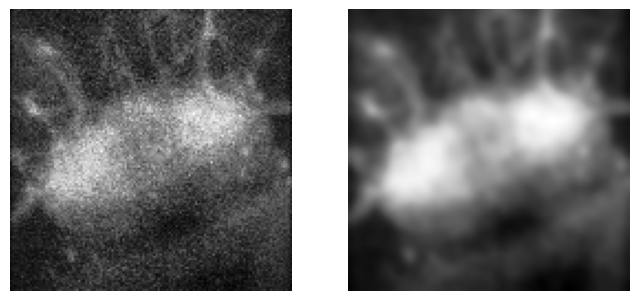

In [37]:
numRefImg = 40



if not exists(preprocDir): makedirs(sep.join([preprocDir]))
np.save(sep.join([preprocDir,'refstartLoc1']), refstartLoc1)
np.save(sep.join([preprocDir,'refstartLoc2']), refstartLoc2)

refImg = imp.genReference(imgStack, numRefImg, refstartLoc1, refstartLoc2, ref_as_fraction=False, maxProject = True)

from scipy.ndimage.filters import gaussian_filter
refImgFilt = gaussian_filter(refImg, sigma=2)

fig, axs = plt.subplots(1,2,figsize=(8,4))
axs[0].imshow(refImg,cmap='Greys_r', origin='lower'); axs[0].axis('off');
axs[1].imshow(refImgFilt,cmap='Greys_r', origin='lower'); axs[1].axis('off');

perform motion correction on a single plane/max projection
. . . . . . . . . . . . . . . . . . . . 

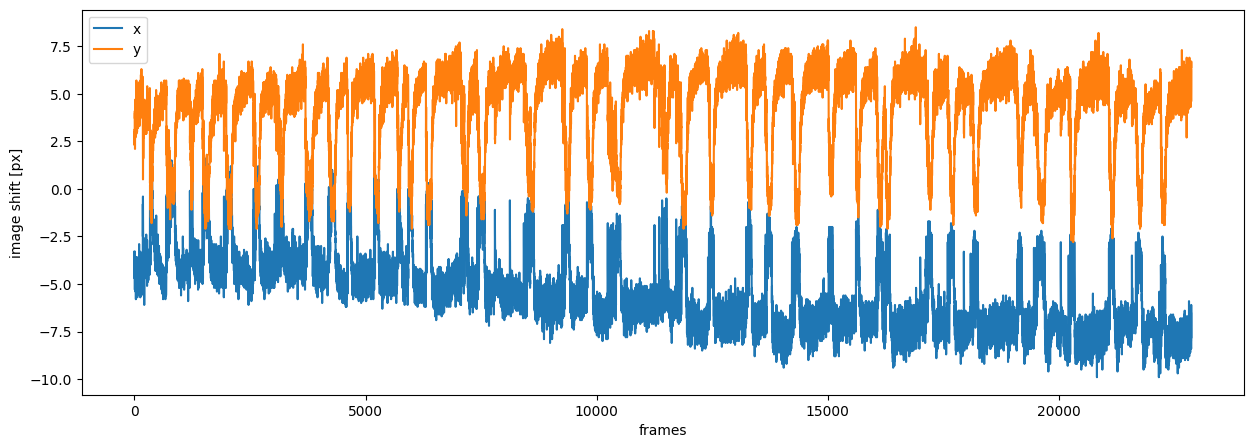

In [38]:
# If there are unreasonable shifts select "doFilter=True".

shift = imp.computeMotionShift(stackMP, refImg, 10, 2, doFilter=False, stdFactor=2, showShiftFig=True)

# stack max projection (MP) motion correction (MC)
stackMPMC = imp.motionCorrection(stackMP, shift)


#shift = imp.computeMotionShift(stackMP, refImg, 10, 2, doFilter=True, stdFactor=4, showShiftFig=True)
#stackMPMC = imp.motionCorrection(stackMP, shift)

In [39]:
napari.view_image(stackMPMC,colormap='plasma')

Viewer(camera=Camera(center=(0.0, 63.5, 63.5), zoom=4.1636718749999995, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(11434.0, 1.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=3, ndisplay=2, last_used=0, range=((0.0, 22869.0, 1.0), (0.0, 128.0, 1.0), (0.0, 128.0, 1.0)), current_step=(11434, 63, 63), order=(0, 1, 2), axis_labels=('0', '1', '2')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'stackMPMC' at 0x25b2be3d9d0>], help='use <2> for transform', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='napari', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse_double_click_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x0000025B13A6B9D0>], _persisted_mouse_event={}, _mouse_drag_gen={}, _mouse_wheel_gen={}, keymap={})

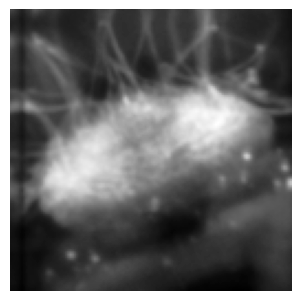

In [40]:
fig, axs = plt.subplots(1,2,figsize=(8,4))

axs[0].imshow(stackMPMC.mean(axis=0), cmap='Greys_r', origin='lower')
axs[0].axis('off')

fig.delaxes(axs[1])  # remove right panel

plt.show()  # display the image

fig.savefig(saveDir + sep + 'anatomyStack_MIP_3d.pdf')

#### Compute DFF

In [41]:
## Settings
# settings for Savitzky-Golay filter (default: 3rd order, 7 frames)
savgol = True
order = 3
window = 7

# Currently F_0 is estimated for each pixel on the whole time series (ok, if time series is short)
baseLinePercent = 10
offset = 0.0001

***Specify region for background subtraction***
* Paint a small region named "background" using a brush in the Labels menu in the napari gui. This region should not overlap with the intended signal roi.
* If there is an existing mask placed in the preprocessing folder of the fly and/or tiral, it will be loaded automatically
* If subtracting using rolling ball, skip the next 2 cells

In [42]:

headerDir = r"\\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\R57C10_x_gCamP6m_tdTomato\aFly_0001"

# you can draw a mask on the foreground
viewer = napari.view_image(stackMPMC.mean(axis=0), contrast_limits=[stackMPMC.data.mean(axis=0).min(),np.percentile(stackMPMC.mean(axis=0), 99.9)])

if exists(sep.join([headerDir,'background_3d.npy'])):
    background = np.load(sep.join([headerDir,'background_3d.npy'])) 
    viewer.add_labels(background, name='background')

In [43]:
background = viewer.layers["background"].data

if not exists(preprocDir): makedirs(sep.join([preprocDir]))
np.save(sep.join([preprocDir,'background_3d']), background)
viewer.close()

plt.imshow(background);
plt.title("Background Mask");

KeyError: "'background' is not in list"

In [ ]:

dffStack, stackF0 = imp.computeDFF(stackMPMC, savgol, order, window, baseLinePercent, offset, subtract=True, background_mask = background, gaussian_sigma = [0,3,3])
dffXarray = imp.stack2xarray(dffStack, basicMetadat, data4D = False)
F0Xarray = imp.refStack2xarray(stackF0, basicMetadat, data4D = False)

meanDFF = np.nanmean(dffXarray, axis=1)
meanDFF2= np.nanmean(meanDFF, axis=1)

meanF0 = np.nanmean(F0Xarray)


processing 3d stack


In [ ]:
meanDFFall = np.nanmean(dffXarray)
meanDFFall


0.6992401051846614

In [ ]:
napari.view_image(dffStack)

Viewer(camera=Camera(center=(0.0, 63.5, 63.5), zoom=4.1636718749999995, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(4409.0, 1.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=3, ndisplay=2, last_used=0, range=((0.0, 8820.0, 1.0), (0.0, 128.0, 1.0), (0.0, 128.0, 1.0)), current_step=(4409, 63, 63), order=(0, 1, 2), axis_labels=('0', '1', '2')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'dffStack' at 0x1bebb903d90>], help='use <2> for transform', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='napari', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse_double_click_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x000001BE002779D0>], _persisted_mouse_event={}, _mouse_drag_gen={}, _mouse_wheel_gen={}, keymap={})

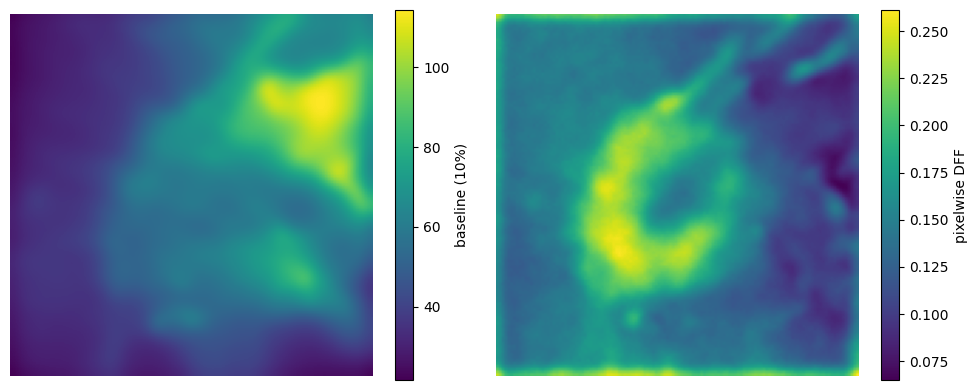

In [ ]:
dffMP = np.mean(dffStack,axis=0)
fig, ax = plt.subplots(1,2,figsize=(10,4))
cb = ax[0].imshow(stackF0,cmap='viridis',origin='upper')#, vmin=0, vmax=10)
plt.colorbar(cb, ax=ax[0], label='baseline ({}%)'.format(baseLinePercent))
ax[0].axis('off')
cb = ax[1].imshow(dffMP,cmap='viridis',origin='upper')#, vmin=0, vmax=10)
plt.colorbar(cb, ax=ax[1], label='pixelwise DFF')
ax[1].axis('off')
fig.tight_layout()
#viewerdff = napari.view_image(dffStackMC)
fig.savefig(saveDir+sep+'BaselineAndDFF_MIP_3d.pdf')

In [ ]:
viewer = napari.view_image(dffStack)
viewer = viewer.add_image(stackMP.mean(axis=0), opacity=0.5)

#### Generate ROIs and split into 16 or 32 wedges

In [ ]:
# draw a mask to constrain which pixels will be included inthe correlation analysis
#viewer = napari.view_image(dffMP)

viewer = napari.view_image(dffMP)
#viewer = napari.view_image(stackMP.mean(axis=0))
if exists(sep.join([headerDir,'EBctr.npy'])):
    ebcenter = np.load(sep.join([headerDir,'EBctr.npy']))
    eblongax = np.load(sep.join([headerDir,'EBlax.npy']))
    ebshortax = np.load(sep.join([headerDir,'EBsax.npy']))
    viewer.add_points(ebcenter, size=5, name='EBctr')
    viewer.add_shapes(eblongax, name='EBlax', shape_type='line', edge_color='cyan')
    viewer.add_shapes(ebshortax,name='EBsax',shape_type='line',edge_color='blue')
    

In [ ]:
ebcenter = viewer.layers["EBctr"].data[0]
eblongax = viewer.layers["EBlax"].data[0]
ebshortax = viewer.layers["EBsax"].data[0]
if not exists(sep.join([preprocDir])): makedirs(sep.join([preprocDir]))
np.save(sep.join([preprocDir,'EBctr']), ebcenter)
np.save(sep.join([preprocDir,'EBlax']), eblongax)
np.save(sep.join([preprocDir,'EBsax']), ebshortax)
viewer.close()

#### bottom of short axis is 0 

In [ ]:
# bottom of short axis is 0 
# bottom of short axis is 0 
# bottom of short axis is 0 
# bottom of short axis is 0 
# bottom of short axis is 0 
# bottom of short axis is 0 

EBslices=15
startLoc=10

condition = '15 degree bar'

EB center coordinates (px): [65.66155248 60.49784072]
EB axis lengths:  axis 1 = 37, axis 2 = 34
EB main axis rotation (deg): 32


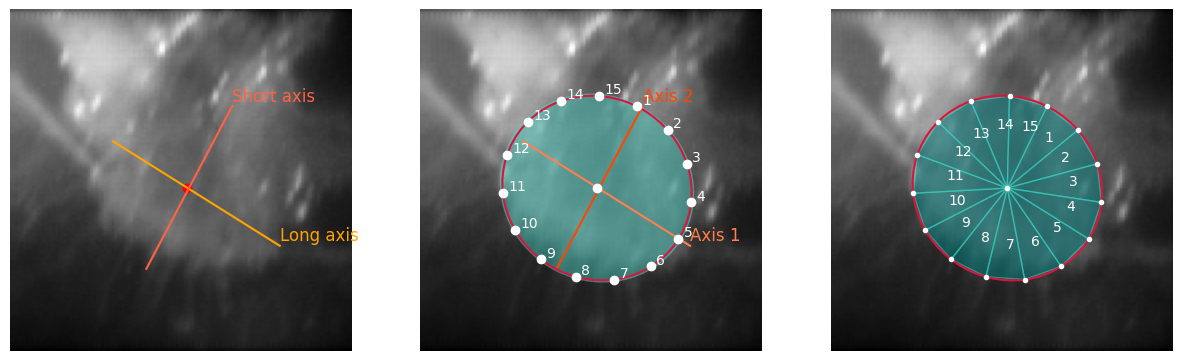

In [ ]:
# note: if EB ellipse is skewed, edit generateEBellipse to rotate the shape

EBaxisL, EBaxisS, ellipseRot, ebcenter, EBoutline = generateEBellipse(eblongax,ebshortax,ebcenter,printResults = True)
EBroiPts, EBroiPolys = constructEBROIs(ebcenter, EBoutline, nsteps=EBslices, st=startLoc)

refEBimg = np.mean(stackMPMC,axis=0).T
fig = plotEBshapelyROIs(refEBimg, ebcenter, EBaxisL, EBaxisS, ellipseRot, EBoutline, EBroiPts, EBroiPolys)
fig.savefig(saveDir+sep+'_'.join(['polyRoiConstruction',genotype, region, flyID, condition, trial])+'.pdf')

In [ ]:
dffROI = getDFFfromEllipseROI(EBroiPts,EBroiPolys,dffXarray)
time = dffXarray.coords['volumes [s]'].values

#### Find F0 values

In [ ]:
stackMPMCXarray = imp.stack2xarray(stackMPMC, basicMetadat, data4D = False)
rawStackROI = getDFFfromEllipseROI(EBroiPts,EBroiPolys,stackMPMCXarray)
rawStackROI.shape


(15, 8820)

In [ ]:
rows, cols = rawStackROI.shape
baseline_percent = 10
threshold = np.percentile(rawStackROI,baseline_percent,axis=1,keepdims=False)

for ri in range(rawStackROI.shape[0]):
    roiF0 = rawStackROI[ri,rawStackROI[ri,:] <= threshold[ri]]

    # padding to make each row the same length in order to stack 
    if len(roiF0)<cols:
        pad_cols = cols-len(roiF0)
        padding = np.empty((pad_cols))
        padding[:] = np.nan
        roiF0 = np.append(roiF0,padding)

    # stack each array
    if ri==0:
        F0stackROI = roiF0
    else:
        F0stackROI = np.vstack((F0stackROI,roiF0))



In [ ]:
# F0 mean for each ROI
F0roiMeans = np.nanmean(F0stackROI, axis=1)
avg_F0roiMeans = np.mean(F0roiMeans)
F0roiMeans

array([56.31528504, 52.68167923, 50.85629949, 48.05977838, 46.35919897,
       45.12901095, 43.30004854, 44.75371421, 45.81043394, 54.39717914,
       61.04945641, 66.30846943, 61.99290367, 53.67929864, 53.64866779])

In [ ]:
# F0 stdev for each ROI
F0roiSTD = np.nanstd(F0stackROI, axis=1)
avg_F0roiSTD = np.mean(F0roiSTD)
F0roiSTD

array([2.92568947, 2.78980523, 2.59445613, 2.55314936, 2.3106701 ,
       2.3148155 , 2.30879975, 2.41182915, 2.51296915, 2.72340905,
       2.70345171, 2.757389  , 2.90540697, 2.54984714, 2.65783769])

#### Find dF/F values as a percent

In [ ]:
rawRoiF = np.nanmean(rawStackROI,axis=1)

roiDfof = ((rawRoiF-F0roiMeans)/F0roiMeans)*100

avg_roiDfof = np.mean(roiDfof)

#### find maximum dF (99th percentile - 1st percentile)

In [ ]:
thresholdLow = 1
threshfoldHigh = 99

rawFlow = np.percentile(rawStackROI,thresholdLow,axis=1,keepdims=False)
rawFhigh = np.percentile(rawStackROI,threshfoldHigh,axis=1,keepdims=False)

maxdF = rawFhigh-rawFlow
avg_maxdF = np.nanmean(maxdF)

#### save data for group statistics 

In [ ]:
# save values into group statistics folder

'''
F0roiMeans # F0 for each ROI
avg_F0roiMeans # avg F0 for fly
F0roiSTD # std of F0 for each ROI
avg_F0roiSTD # avg F0 std for fly
avg_roiDfof # dF/F for fly as a percent
maxdF # max dF = 99th-1st percentile
avg_maxdF # max dF avg for fly
 '''
statsDf = np.append(avg_F0roiMeans,avg_F0roiSTD)
statsDf = np.append(statsDf,avg_roiDfof)
statsDf = np.append(statsDf,avg_maxdF)

statsDf = statsDf[...,None]
statsDf = statsDf.T

# create df
statsDf = pd.DataFrame(data=statsDf, columns = ['avg_F0roiMeans','avg_F0roiSTD','avg_roiDfof','avg_maxdF'])
statsDf.insert(0,'flyID',flyID)
statsDf.insert(1,'genotype',genotype)
statsDf.insert(2,'age',age)

statsDf





,flyID,genotype,age,avg_F0roiMeans,avg_F0roiSTD,avg_roiDfof,avg_maxdF
0,f01,R57C10_x_27F02-7f_SCaMP77,1to2,52.289428,2.601302,29.122823,57.45797


In [ ]:
# df to csv
'''outFile = r'\\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\SS96_x_jRGECO1a\groupStats'
outFile = (outFile+sep+'_'.join(['groupStats',genotype, flyID])+'.csv')
statsDf.to_csv(outFile, encoding='utf-8', index=False)'''
# statsDf.to_csd('\\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\SS96_x_sCaMP77D4\groupStats', encoding='utf-8', index=False)
# statsDf.to_csd('\\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\SS96_x_jRGECO1a\groupStats', encoding='utf-8', index=False)

"outFile = r'\\prfs.hhmi.org\\jayaramanlab\\Abby\\Data\\Fly2PImaging\\SS96_x_jRGECO1a\\groupStats'\noutFile = (outFile+sep+'_'.join(['groupStats',genotype, flyID])+'.csv')\nstatsDf.to_csv(outFile, encoding='utf-8', index=False)"

#### Generate data object and save to disk

In [ ]:
# create dataframe for the ROI data
# align it to time
roiDf = pd.DataFrame(data=dffROI.T, columns = ['slice{}'.format(i+1) for i in range(len(EBroiPts)-1)])
roiDf['time [s]'] = time
roiDf.head()

,slice1,slice2,slice3,slice4,slice5,slice6,slice7,slice8,slice9,slice10,slice11,slice12,slice13,slice14,slice15,time [s]
0,0.388594,0.565649,0.546496,0.700261,0.617742,0.689584,0.634836,0.672871,0.565174,0.614288,0.591907,0.549208,0.559442,0.725511,0.496933,0.000000
1,0.421440,0.488358,0.564893,0.595303,0.593496,0.553465,0.631371,0.751562,0.692879,0.628765,0.645901,0.610114,0.549518,0.594177,0.558618,0.102019
2,0.473113,0.515882,0.574344,0.558509,0.622340,0.593344,0.689543,0.777277,0.731349,0.676947,0.661420,0.649527,0.545235,0.538294,0.575624,0.204038
3,0.544312,0.593748,0.583251,0.575086,0.676042,0.722133,0.764008,0.769599,0.725370,0.732609,0.657793,0.673640,0.555825,0.540443,0.568549,0.306057
4,0.667436,0.633556,0.614224,0.627821,0.681507,0.791749,0.753867,0.744600,0.742762,0.723180,0.633063,0.678763,0.608323,0.571987,0.548720,0.408075


C:\Users\stuarta\AppData\Local\Temp\ipykernel_38664\340110134.py:4: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  patch = ppatch.Ellipse(ebcenter, EBaxisL.length, EBaxisS.length, -ellipseRot, alpha = 0.4, color='tomato')


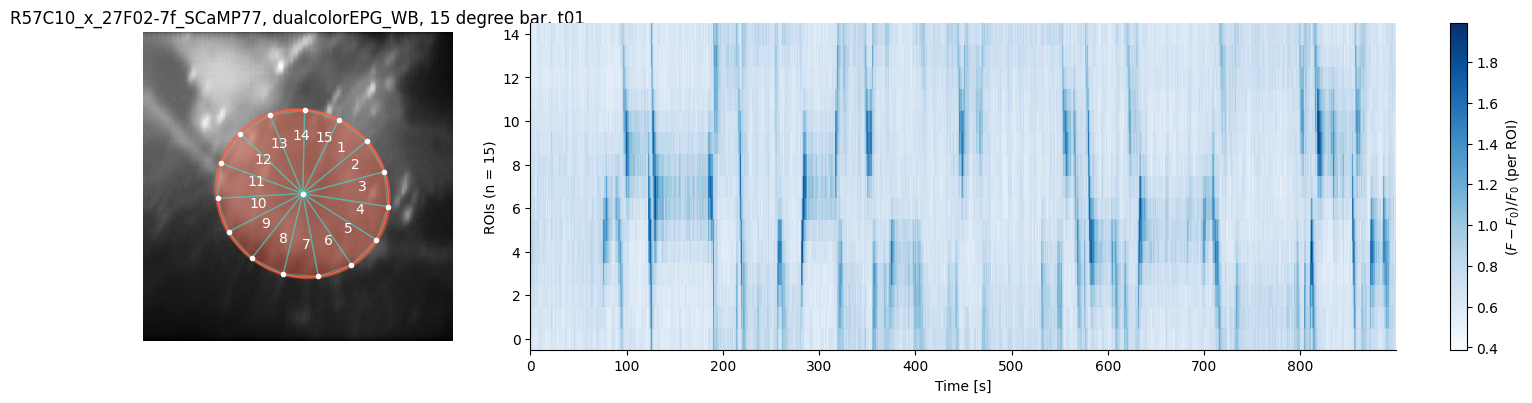

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(15,4),gridspec_kw={'width_ratios':[1,3.5]})
axs[0].imshow(np.mean(stackMPMC,axis=0).T,cmap='Greys_r', origin='lower')#, vmin=0, vmax=0.7*np.max(stackMP))

patch = ppatch.Ellipse(ebcenter, EBaxisL.length, EBaxisS.length, -ellipseRot, alpha = 0.4, color='tomato')

axs[0].add_patch(patch)
axs[0].plot(EBoutline.coords.xy[0],EBoutline.coords.xy[1], color='tomato', linewidth=1)

for s in range(len(EBroiPts)-1):
    roiPatch = ppatch.Polygon(EBroiPolys[s],alpha=0.4, edgecolor='turquoise', facecolor='none')
    axs[0].add_patch(roiPatch)
    axs[0].plot(EBroiPts[s+1][0],EBroiPts[s+1][1], 'w.')
    labcoord = Polygon(EBroiPolys[s]).centroid.coords.xy
    axs[0].text(labcoord[0][0],labcoord[1][0], str(s+1), color='w')

axs[0].plot(EBroiPts[0][0],EBroiPts[0][1], 'w.')
axs[0].axis('off')
axs[0].set_title(', '.join([genotype, region, condition, trial]))

axs[1] = plotDFFheatmap(time, dffROI, axs[1], fig)
myAxisTheme(axs[1])

fig.tight_layout()
fig.savefig(saveDir+sep+'_'.join(['roiMap-dFFtimeseries',genotype, region, flyID, condition, trial])+'.pdf')

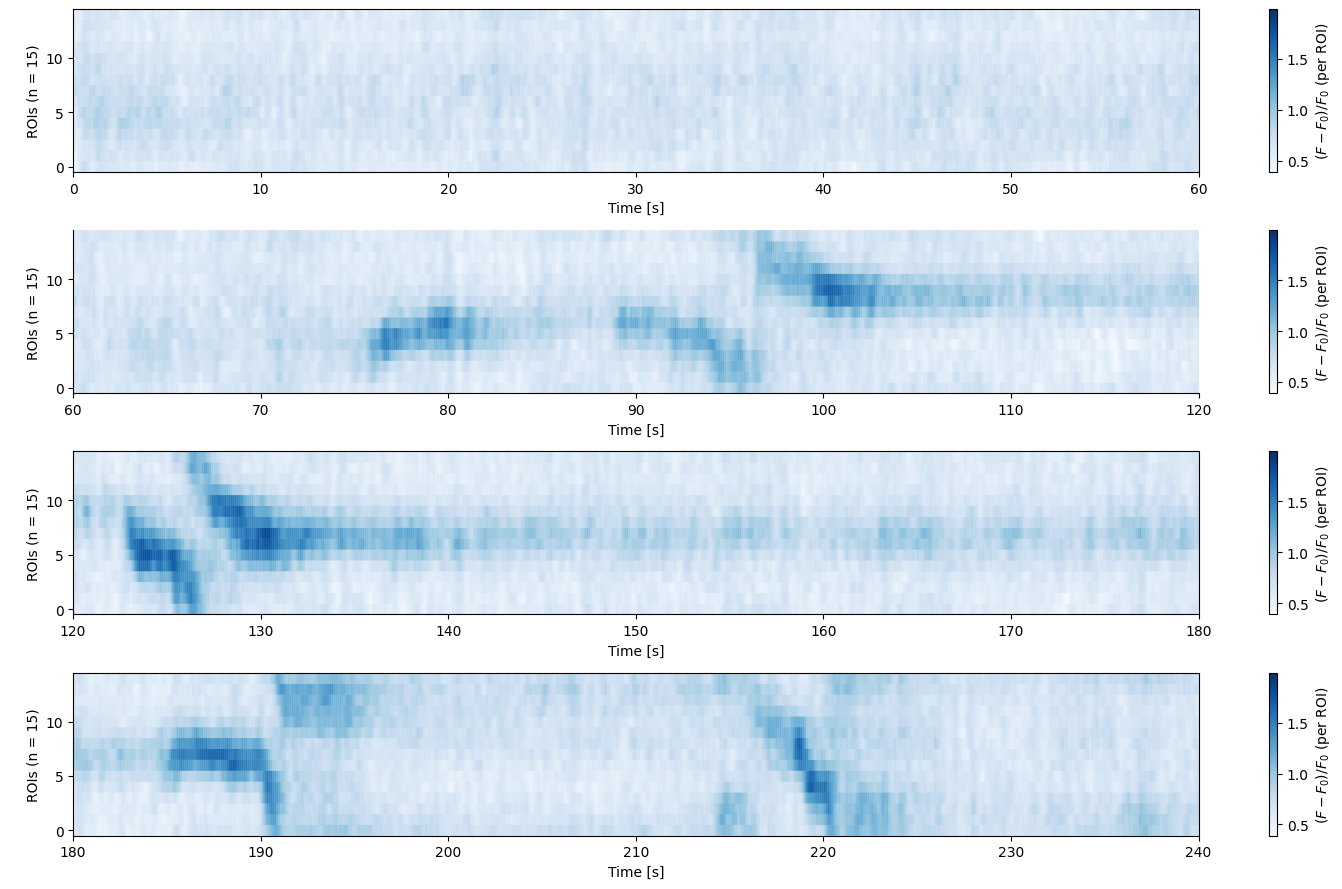

In [ ]:

fig, axs = plt.subplots(4,1,figsize=(15, 9))

# axs[0] = plotDFFheatmap(time, dffROI, axs[0], fig) #vmax=1.5)
# axs[0].set_xlim(0,15*60)

# axs[1] = plotDFFheatmap(time, dffROI, axs[1], fig) #vmax=1.5)
# axs[1].set_xlim(15*60,2*15*60)

# axs[2] = plotDFFheatmap(time, dffROI, axs[2], fig) #vmax=1.5)
# axs[2].set_xlim(2*15*60,3*15*60)

# axs[3] = plotDFFheatmap(time, dffROI, axs[3], fig) #vmax=1.5)
# axs[3].set_xlim(3*15*60,4*15*60)

axs[0] = plotDFFheatmap(time, dffROI, axs[0], fig) #vmax=1.5)
axs[0].set_xlim(0,60)

axs[1] = plotDFFheatmap(time, dffROI, axs[1], fig) #vmax=1.5)
axs[1].set_xlim(60,120)

axs[2] = plotDFFheatmap(time, dffROI, axs[2], fig) #vmax=1.5)
axs[2].set_xlim(120,180)

axs[3] = plotDFFheatmap(time, dffROI, axs[3], fig) #vmax=1.5)
axs[3].set_xlim(180,240)

myAxisTheme(axs[1])

fig.tight_layout()
fig.savefig(saveDir+sep+'_'.join(['roiMap-dFFtimeseries60s',genotype, region, flyID, condition, trial])+'.pdf')


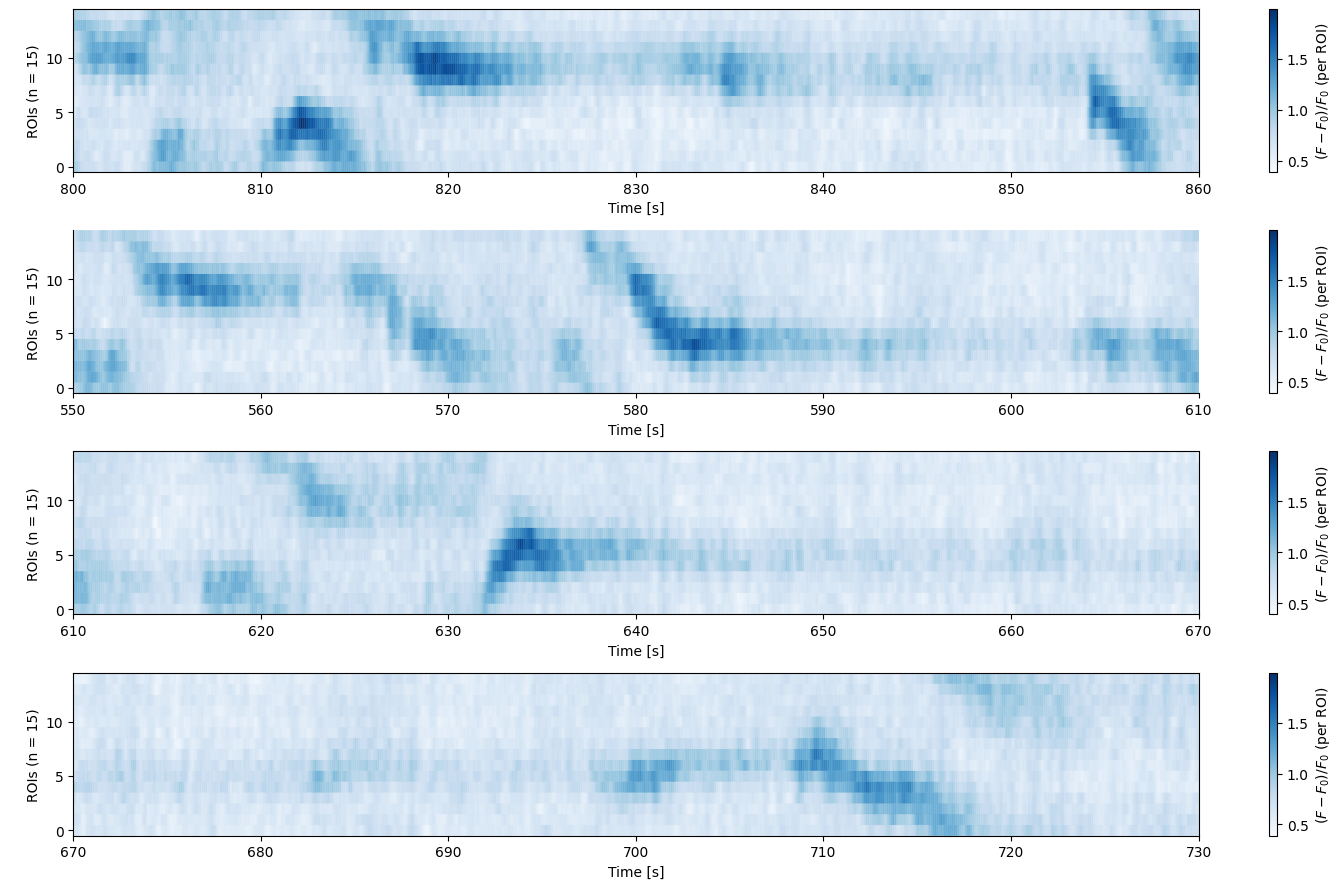

In [ ]:
fig, axs = plt.subplots(4,1,figsize=(15, 9))

axs[0] = plotDFFheatmap(time, dffROI, axs[0], fig) #vmax=1.5)
axs[0].set_xlim(800,860)

axs[1] = plotDFFheatmap(time, dffROI, axs[1], fig) #vmax=1.5)
axs[1].set_xlim(550,610)

axs[2] = plotDFFheatmap(time, dffROI, axs[2], fig) #vmax=1.5)
axs[2].set_xlim(610,670)

axs[3] = plotDFFheatmap(time, dffROI, axs[3], fig) #vmax=1.5)
axs[3].set_xlim(670,730)

myAxisTheme(axs[1])

fig.tight_layout()
fig.savefig(saveDir+sep+'_'.join(['roiMap-dFFtimeseriesZooms',genotype, region, flyID, condition, trial])+'.pdf')


#### Compute PVA

In [61]:
def computePVA (locs, weights):
    # compute population vector average

    nsteps = weights.shape[0]
    nvol = weights.shape[1]
    pva_x = np.cos(np.reshape(np.tile(locs,nvol),[nvol,nsteps])).T*weights
    pva_y = np.sin(np.reshape(np.tile(locs,nvol),[nvol,nsteps])).T*weights

    pva = np.vstack((sum(pva_x)/len(pva_x), sum(pva_y)/len(pva_x)))
    return pva


In [62]:
nsteps = EBslices
roiArcPos = np.linspace(0,2*np.pi,nsteps+1)[:-1]



pva = computePVA(roiArcPos,dffROI)
pvaRad = np.arctan2(pva[1,:],pva[0,:])
pvaLen = np.hypot(pva[0,:],pva[1,:])

PVAst = 3#7.5
pvaROI = np.mod((np.unwrap(pvaRad,np.pi) - pvaRad[0]) * nsteps/(2*np.pi) + PVAst, nsteps)

In [63]:
#plt.plot(time, computePVA(roiArcPos,dffROI)[0],'k')
#plt.plot(time,)
#pva.shape

In [64]:
# remove jumps from plotted PVA values
eps = 7./3-4./3-1
pvaRadnan = pvaRad
pvaRadnan[np.abs(pvaRadnan)>np.pi-0.02] = np.NaN

max(pvaRad)


3.1214291804047485

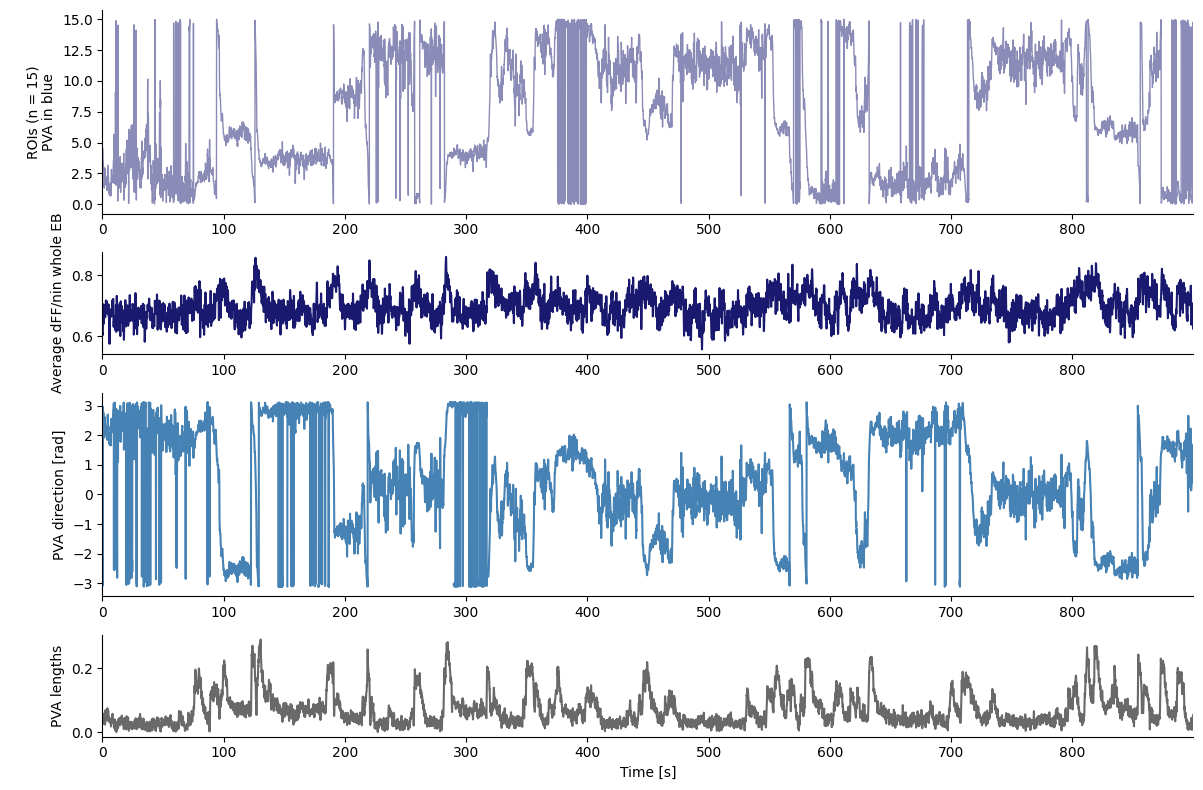

In [65]:
fig, axs = plt.subplots(4,1,figsize=(12,8),gridspec_kw={'height_ratios':[1,0.5,1,0.5]})

#cax = axs[0].pcolor(time,np.arange(0,nsteps+1),dffROI,cmap='Blues',edgecolors='face')
#cax = ax.pcolor(time,np.arange(0,dffROI.shape[0]),dffROI,cmap='Blues',edgecolors='face',shading='auto')

axs[0].set_ylabel('\nROIs (n = {0})\nPVA in blue'.format(nsteps))
axs[0].plot(time,pvaROI,'-',color='midnightblue',linewidth=1,alpha=0.5)

axs[1].plot(time,meanDFF2,color='midnightblue')
axs[1].set_ylabel('Average dFF/nin whole EB')

axs[2].plot(time,pvaRadnan,color='steelblue')
axs[2].set_ylabel('PVA direction [rad]')

axs[3].plot(time,pvaLen,color='dimgrey')
axs[3].set_ylabel('PVA lengths')
axs[3].set_xlabel('Time [s]')

for ax in axs:
    myAxisTheme(ax)
    ax.set_xlim(time[0],time[-1])

fig.tight_layout()
#fig.savefig(saveDir)

#### Generate dataframe and save

In [66]:
nsteps = EBslices
roiArcPos = np.linspace(0,2*np.pi,nsteps+1)[:-1]



pva = computePVA(roiArcPos,dffROI)
pvaRad = np.arctan2(pva[1,:],pva[0,:])
pvaLen = np.hypot(pva[0,:],pva[1,:])

PVAst = 3#7.5
pvaROI = np.mod((np.unwrap(pvaRad,np.pi) - pvaRad[0]) * nsteps/(2*np.pi) + PVAst, nsteps)

In [67]:
# create dataframe for the ROI data
# align it to time
#column_names = ['pvaRad','pvaLen']
pvaDf = pd.DataFrame({'pvaRad':pvaRad.T, 'pvaLen':pvaLen.T, 'pvaROI':pvaROI.T})

pvaDf.insert(3,"time [s]",time) #-1 ?
pvaDf.head()

,pvaRad,pvaLen,pvaROI,time [s]
0,2.629705,0.029407,3.000000,0.000000
1,-3.004672,0.043783,4.548916,0.102019
2,-3.073063,0.052501,4.385645,0.204038
3,2.960163,0.053996,3.788911,0.306057
4,2.745558,0.041997,3.276579,0.408075


#### Generate data object and save to disk

In [68]:
expMetadata = {
    'tiffilename': rawTiff,
    'genotype': genotype,
    'flyid': flyID,
    'trial':trial,
    'condition':'test',
    'roitype': "corr",
    'brainregion': region
}

imgTS_corrroi = imp.imagingTimeseries(
    imgMetadata = basicMetadat,
    expMetadata = expMetadata,
    refImage = refImg, 
    dffStack = dffXarray, 
    F0stack = F0Xarray,
    roitype = "ellipse",
    roiMask = "none", #kmlabsImg, 
    roiDFF = roiDf
)

path2imgdat = imgTS_corrroi.saveData(preprocDir,'')

In [69]:
#pvaDf.to_csv(sep.join([preprocDir,'roiDf.csv',index=False)
#roiDf.to_csv(sep.join([saveDir,'roiDf.csv']))

In [102]:
#kmlabsImg = np.nan*np.ones(mask.data.shape)

In [103]:
"""roiDf = pd.DataFrame(data = centroids.T, columns = ['roi{}'.format(i+1) for i in range(nclst)])
roiDf['time [s]'] = time
roiDf.head()"""

"roiDf = pd.DataFrame(data = centroids.T, columns = ['roi{}'.format(i+1) for i in range(nclst)])\nroiDf['time [s]'] = time\nroiDf.head()"

In [104]:
expMetadata = {
    'tiffilename': rawTiff,
    'genotype': genotype,
    'flyid': flyID,
    'trial':trial,
    'condition':'test',
    'roitype': "corr",
    'brainregion': region
}

imgTS_corrroi = imp.imagingTimeseries(
    imgMetadata = basicMetadat,
    expMetadata = expMetadata,
    refImage = refImg, 
    dffStack = dffXarray, 
    F0stack = F0Xarray,
    roitype = "ellipse",
    roiMask = "none", #kmlabsImg, 
    roiDFF = roiDf
)

path2imgdat = imgTS_corrroi.saveData(preprocDir,'')

In [105]:
preprocDir

'\\\\prfs.hhmi.org\\jayaramanlab\\Abby\\Data\\Fly2PImaging\\ss96_x_SCaMP3048474\\aFly_0002\\t03\\t03'

In [106]:
roiDf.shape

(5880, 17)

In [107]:
# To load data from previously save files into object: 
path2imgdat = r"\\prfs.hhmi.org\jayaramanlab\Abby\Data\Fly2PImaging\SS96_x_sCaMP77D4\f11\img"
imgTS_load = imp.loadImagingTimeseries(path2imgdat)